In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 16.4 MB/s eta 0:00:0000:01


In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import jaccard_score
import skfuzzy as fuzz
from scipy.ndimage import binary_erosion, binary_dilation
from scipy.spatial.distance import directed_hausdorff

In [15]:
base_path = "/kaggle/input/datasets/jeetblahiri/bccd-dataset-with-mask/BCCD Dataset with mask"

img_dir  = os.path.join(base_path, "train/original")
mask_dir = os.path.join(base_path, "train/mask")


image_files = sorted(os.listdir(img_dir))
img_name = image_files[0]

img_path  = os.path.join(img_dir, img_name)
mask_path = os.path.join(mask_dir, img_name.replace(".jpg",".png"))

img = cv2.imread(img_path)
gt_mask = cv2.imread(mask_path,0)

img = cv2.resize(img,(256,256))
gt_mask = cv2.resize(gt_mask,(256,256))
gt_mask = (gt_mask > 127).astype(np.uint8)

In [17]:


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
pixels = lab.reshape((-1,3)).astype(np.float32)

k = 3


kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(pixels)

seg_kmeans = labels_kmeans.reshape(256,256)

centers = kmeans.cluster_centers_
nucleus_cluster = np.argmin(centers[:,0])
nucleus_mask_kmeans = (seg_kmeans == nucleus_cluster).astype(np.uint8)



In [18]:
data = pixels.T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data, c=k, m=2, error=0.005, maxiter=1000
)

nucleus_cluster_fcm = np.argmin(cntr[:,0])
membership = u[nucleus_cluster_fcm].reshape(256,256)

nucleus_mask_fcm = (membership > 0.5).astype(np.uint8)


gt = gt_mask.flatten()
km = nucleus_mask_kmeans.flatten()
fcm = nucleus_mask_fcm.flatten()

iou_kmeans = jaccard_score(gt, km)
iou_fcm = jaccard_score(gt, fcm)



In [19]:


def extract_boundary(mask):
    eroded = binary_erosion(mask)
    boundary = mask.astype(bool) & ~eroded
    return boundary.astype(np.uint8)

def hausdorff_distance(mask1, mask2):
    pts1 = np.argwhere(mask1)
    pts2 = np.argwhere(mask2)
    if len(pts1)==0 or len(pts2)==0:
        return float('inf')
    d1 = directed_hausdorff(pts1, pts2)[0]
    d2 = directed_hausdorff(pts2, pts1)[0]
    return max(d1,d2)

def boundary_f1_score(pred_boundary, gt_boundary, tolerance=2):

    struct = np.ones((2*tolerance+1, 2*tolerance+1))

    gt_dilated   = binary_dilation(gt_boundary,structure=struct)
    pred_dilated = binary_dilation(pred_boundary,structure=struct)

    tp_pred = np.sum(pred_boundary & gt_dilated)
    tp_gt   = np.sum(gt_boundary & pred_dilated)

    precision = tp_pred/(np.sum(pred_boundary)+1e-8)
    recall    = tp_gt/(np.sum(gt_boundary)+1e-8)

    f1 = 2*precision*recall/(precision+recall+1e-8)

    return precision, recall, f1




In [20]:
gt_boundary  = extract_boundary(gt_mask)
km_boundary  = extract_boundary(nucleus_mask_kmeans)
fcm_boundary = extract_boundary(nucleus_mask_fcm)


hd_kmeans = hausdorff_distance(km_boundary, gt_boundary)
hd_fcm    = hausdorff_distance(fcm_boundary, gt_boundary)


prec_km, rec_km, f1_km   = boundary_f1_score(km_boundary, gt_boundary)
prec_fcm, rec_fcm, f1_fcm = boundary_f1_score(fcm_boundary, gt_boundary)



print("=== Hausdorff Distance (lower is better) ===")
print(f"K-Means  Hausdorff Distance : {hd_kmeans:.4f} px")
print(f"FCM      Hausdorff Distance : {hd_fcm:.4f} px")

print("\n=== Boundary F1-Score (higher is better) ===")
print(f"K-Means  | Precision: {prec_km:.4f}  Recall: {rec_km:.4f}  F1: {f1_km:.4f}")
print(f"FCM      | Precision: {prec_fcm:.4f}  Recall: {rec_fcm:.4f}  F1: {f1_fcm:.4f}")

print("\n=== Full Comparison Summary ===")
print(f"{'Metric':<30} {'K-Means':>12} {'FCM':>12}")
print("-" * 54)
print(f"{'IoU Score':<30} {iou_kmeans:>12.4f} {iou_fcm:>12.4f}")
print(f"{'Hausdorff Distance (px)':<30} {hd_kmeans:>12.4f} {hd_fcm:>12.4f}")
print(f"{'Boundary Precision':<30} {prec_km:>12.4f} {prec_fcm:>12.4f}")
print(f"{'Boundary Recall':<30} {rec_km:>12.4f} {rec_fcm:>12.4f}")
print(f"{'Boundary F1-Score':<30} {f1_km:>12.4f} {f1_fcm:>12.4f}")


=== Hausdorff Distance (lower is better) ===
K-Means  Hausdorff Distance : 29.1548 px
FCM      Hausdorff Distance : 29.1548 px

=== Boundary F1-Score (higher is better) ===
K-Means  | Precision: 0.7741  Recall: 0.9552  F1: 0.8552
FCM      | Precision: 0.7808  Recall: 0.9502  F1: 0.8572

=== Full Comparison Summary ===
Metric                              K-Means          FCM
------------------------------------------------------
IoU Score                            0.5918       0.5682
Hausdorff Distance (px)             29.1548      29.1548
Boundary Precision                   0.7741       0.7808
Boundary Recall                      0.9552       0.9502
Boundary F1-Score                    0.8552       0.8572


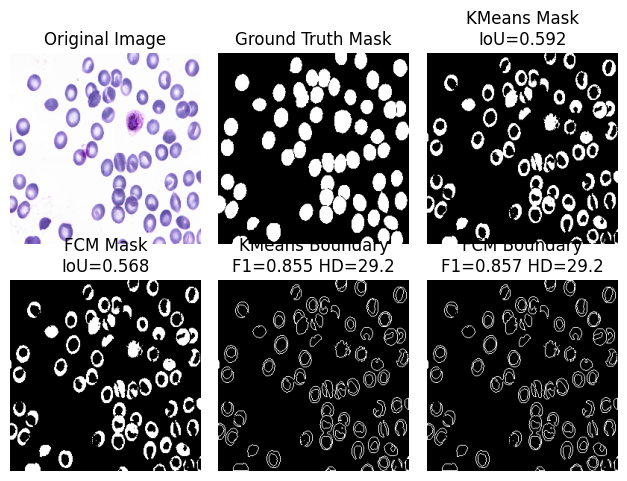

In [21]:


plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

# Ground truth mask
plt.subplot(2,3,2)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

# KMeans segmentation mask
plt.subplot(2,3,3)
plt.imshow(nucleus_mask_kmeans, cmap='gray')
plt.title(f"KMeans Mask\nIoU={iou_kmeans:.3f}")
plt.axis("off")

# FCM segmentation mask
plt.subplot(2,3,4)
plt.imshow(nucleus_mask_fcm, cmap='gray')
plt.title(f"FCM Mask\nIoU={iou_fcm:.3f}")
plt.axis("off")

# KMeans boundary
plt.subplot(2,3,5)
plt.imshow(km_boundary, cmap='gray')
plt.title(f"KMeans Boundary\nF1={f1_km:.3f} HD={hd_kmeans:.1f}")
plt.axis("off")

# FCM boundary
plt.subplot(2,3,6)
plt.imshow(fcm_boundary, cmap='gray')
plt.title(f"FCM Boundary\nF1={f1_fcm:.3f} HD={hd_fcm:.1f}")
plt.axis("off")

plt.tight_layout()
plt.show()